# Zameen.com Property Data Analysis

## Phase 1: Import Libraries and Load Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [12]:
# Load data (delimiter is ';')
df_raw = pd.read_csv("/content/Property.csv", delimiter=";", engine='python')

# # Overview
# display(df_raw.head())
# display(df_raw.tail())

print("Shape (rows, cols):", df_raw.shape)
print("Number of features:", df_raw.shape[1])
print("Columns:", list(df_raw.columns))

# df_raw.info()


Shape (rows, cols): (191393, 17)
Number of features: 17
Columns: ['property_id', 'location_id', 'page_url', 'property_type', 'price', 'location', 'city', 'province_name', 'latitude', 'longitude', 'baths', 'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent']


In [13]:

# Statistical summaries
num_summary = df_raw.select_dtypes(include=[np.number]).describe().T
cat_summary = df_raw.select_dtypes(exclude=[np.number]).describe().T

display(num_summary)
display(cat_summary)


,count,mean,std,min,25%,50%,75%,max
property_id,191393.0,1.573170e+07,2.215249e+06,86575.000000,1.511867e+07,1.676385e+07,1.715282e+07,1.769386e+07
location_id,191393.0,4.224580e+03,3.719125e+03,1.000000,1.057000e+03,3.233000e+03,7.182000e+03,1.424600e+04
price,191393.0,1.644655e+07,3.416412e+07,0.000000,8.000000e+04,7.300000e+06,1.800000e+07,2.000000e+09
latitude,191393.0,3.010459e+01,3.645941e+00,11.052446,2.497229e+01,3.146356e+01,3.355087e+01,7.318409e+01
longitude,191393.0,7.157299e+01,3.080463e+00,25.906027,6.715260e+01,7.307774e+01,7.422822e+01,8.016143e+01
baths,191393.0,2.865956e+00,2.435332e+00,0.000000,0.000000e+00,3.000000e+00,4.000000e+00,4.030000e+02
bedrooms,191393.0,3.171516e+00,1.952403e+00,0.000000,2.000000e+00,3.000000e+00,4.000000e+00,6.800000e+01


,count,unique,top,freq
page_url,191393,191393,https://www.zameen.com/Property/i_10_i_10_2_i_...,1
property_type,191393,7,House,118915
location,191393,1536,DHA Defence,26161
city,191393,5,Karachi,60484
province_name,191393,3,Punjab,90714
area,191393,352,1 Kanal,25452
purpose,191393,2,For Sale,127018
date_added,191393,148,07-03-2019,10400
agency,144014,5923,Mash Allah Estate & Builders,821
agent,144013,11352,Azam Ali,797


## Phase 2: Data Cleaning and Preparation

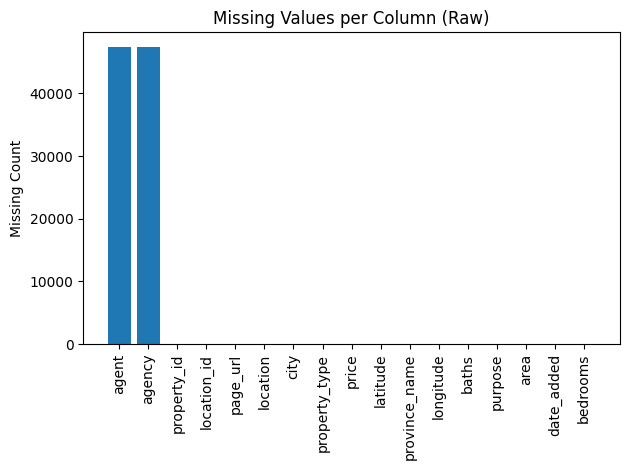

,0
agent,47380
agency,47379
property_id,0
location_id,0
page_url,0
location,0
city,0
property_type,0
price,0
latitude,0


In [14]:

# Missing values per column
missing_counts = df_raw.isna().sum().sort_values(ascending=False)
plt.figure()
plt.bar(missing_counts.index.astype(str), missing_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Missing Count")
plt.title("Missing Values per Column (Raw)")
plt.tight_layout()
plt.show()

display(missing_counts)


In [15]:

# Drop irrelevant columns
df = df_raw.drop(columns=[c for c in ["page_url", "location_id"] if c in df_raw.columns]).copy()

# Ensure numeric columns are numeric
for c in ["price", "baths", "bedrooms", "latitude", "longitude"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Convert area -> marla
def area_to_marla(area_str):
    if pd.isna(area_str):
        return np.nan
    s = str(area_str).strip().lower()
    m = re.match(r"^\s*([\d\.]+)\s*(marla|kanal)\s*$", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    unit = m.group(2)
    if unit == "marla":
        return val
    if unit == "kanal":
        return val * 20.0  # 1 Kanal = 20 Marla
    return np.nan

df["area_in_marla"] = df["area"].apply(area_to_marla)

# Impute categorical/string with "Unknown"
cat_cols = df.select_dtypes(exclude=[np.number]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Impute numeric with mean
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].mean())

# Verification: no missing values remain
print("Total missing values after imputation:", df.isna().sum().sum())
display(df.head())


Total missing values after imputation: 0


,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan,120.0
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B,20.0
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar",9.0
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,Unknown,Unknown,20.0
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,Unknown,Unknown,11.0


## Phase 3: Outlier Detection

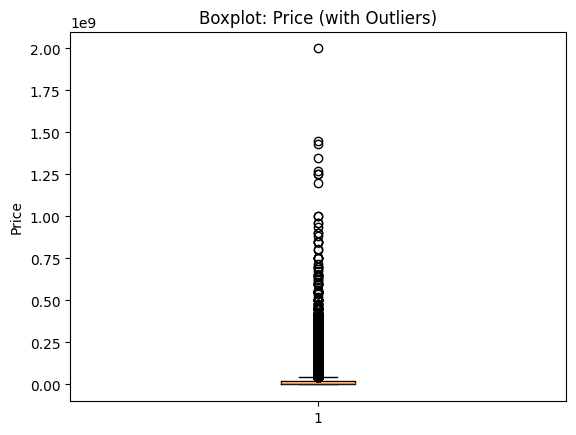

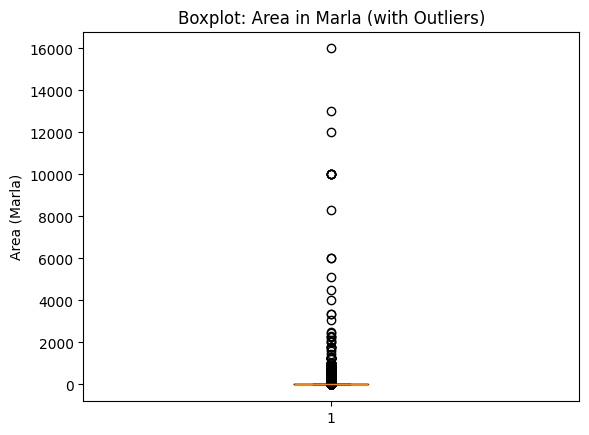

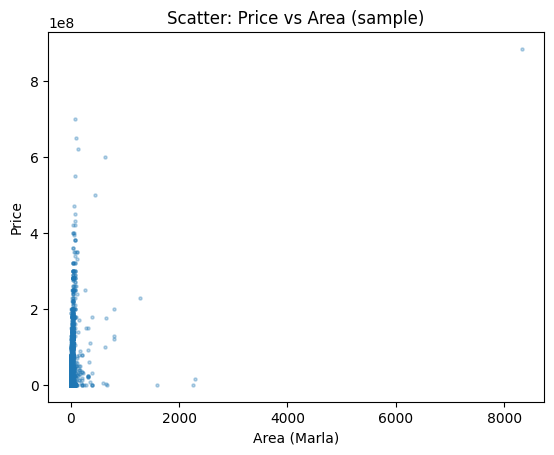

In [16]:

df_vis = df.copy()
df_filtered = df[(df["price"] > 0) & (df["area_in_marla"] > 0)].copy()

# Boxplot: price
plt.figure()
plt.boxplot(df_vis["price"].values, showfliers=True)
plt.ylabel("Price")
plt.title("Boxplot: Price (with Outliers)")
plt.show()

# Boxplot: area_in_marla
plt.figure()
plt.boxplot(df_vis["area_in_marla"].values, showfliers=True)
plt.ylabel("Area (Marla)")
plt.title("Boxplot: Area in Marla (with Outliers)")
plt.show()

# Scatter: price vs area (sample for speed)
sample = df_filtered.sample(n=min(20000, len(df_filtered)), random_state=42)
plt.figure()
plt.scatter(sample["area_in_marla"], sample["price"], s=5, alpha=0.3)
plt.xlabel("Area (Marla)")
plt.ylabel("Price")
plt.title("Scatter: Price vs Area (sample)")
plt.show()


## Phase 4: Exploratory Data Analysis (EDA)
### A) Univariate
### B) Bivariate
### C) Multivariate

In [17]:

# Parse date
df_filtered["date_added_parsed"] = pd.to_datetime(df_filtered["date_added"], errors="coerce")
df_filtered["year_added"] = df_filtered["date_added_parsed"].dt.year
df_filtered["month_added"] = df_filtered["date_added_parsed"].dt.month


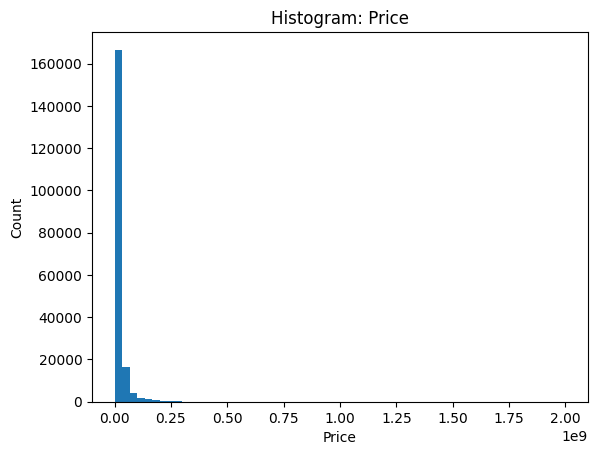

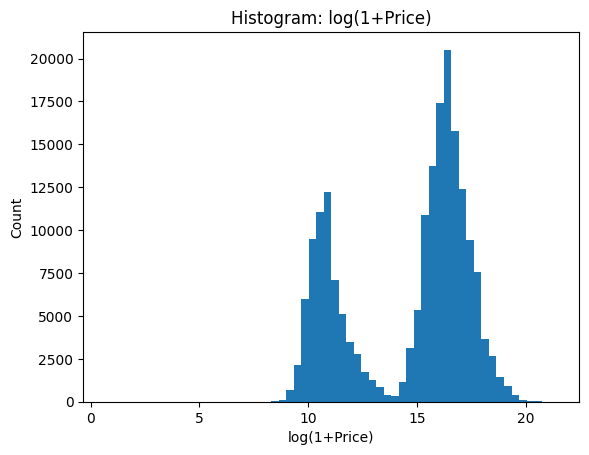

In [18]:

# 1) Price distribution
plt.figure()
plt.hist(df_filtered["price"], bins=60)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Histogram: Price")
plt.show()

plt.figure()
plt.hist(np.log1p(df_filtered["price"]), bins=60)
plt.xlabel("log(1+Price)")
plt.ylabel("Count")
plt.title("Histogram: log(1+Price)")
plt.show()


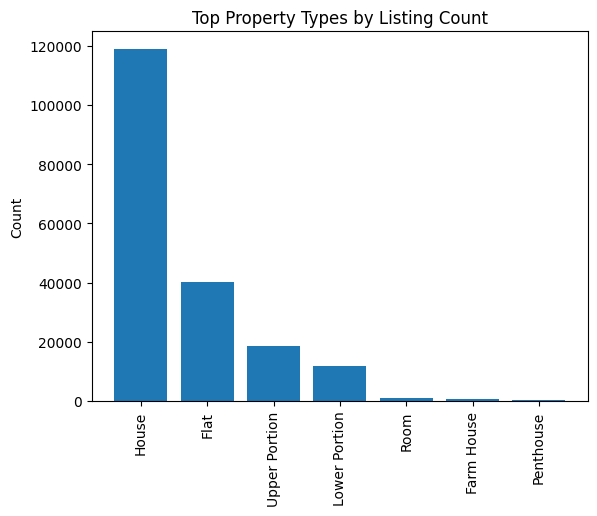

,count
property_type,
House,118901
Flat,40156
Upper Portion,18473
Lower Portion,11692
Room,1029
Farm House,724
Penthouse,399


In [19]:

# 2) Property type counts (top 20)
ptype_counts = df_filtered["property_type"].value_counts().head(20)
plt.figure()
plt.bar(ptype_counts.index.astype(str), ptype_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Top Property Types by Listing Count")
plt.show()

display(ptype_counts)


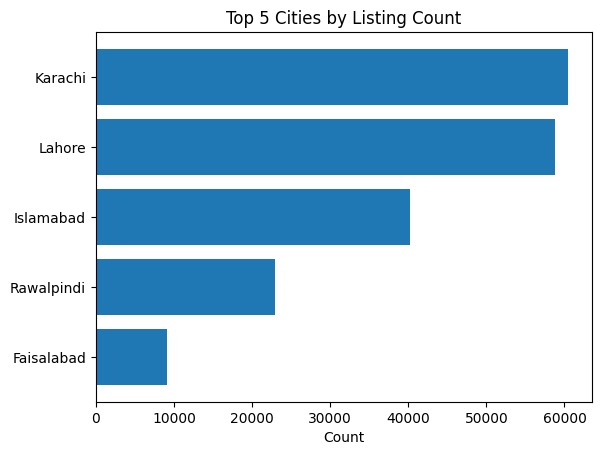

,count
city,
Karachi,60482
Lahore,58731
Islamabad,40187
Rawalpindi,22894
Faisalabad,9080


In [20]:

# 3) Top 5 cities
top5_cities = df_filtered["city"].value_counts().head(5)
plt.figure()
plt.barh(top5_cities.index.astype(str)[::-1], top5_cities.values[::-1])
plt.xlabel("Count")
plt.title("Top 5 Cities by Listing Count")
plt.show()

display(top5_cities)


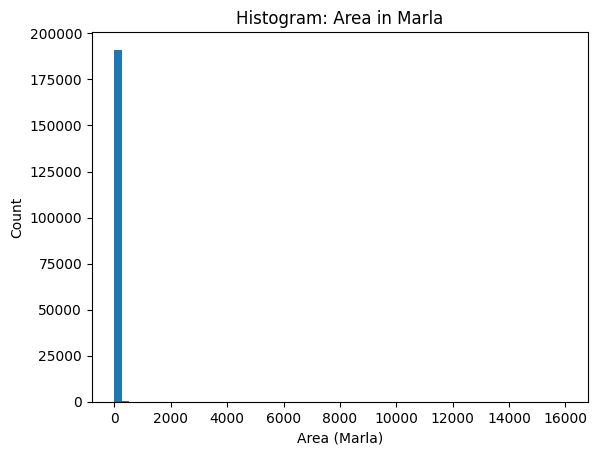

Area (Marla) quantiles:


,area_in_marla
0.50,7.6
0.90,20.0
0.95,24.0
0.99,54.0


In [21]:

# 4) Area distribution
plt.figure()
plt.hist(df_filtered["area_in_marla"], bins=60)
plt.xlabel("Area (Marla)")
plt.ylabel("Count")
plt.title("Histogram: Area in Marla")
plt.show()

print("Area (Marla) quantiles:")
display(df_filtered["area_in_marla"].quantile([0.5, 0.9, 0.95, 0.99]))


/tmp/ipython-input-4055588929.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=top3_cities, showfliers=True)


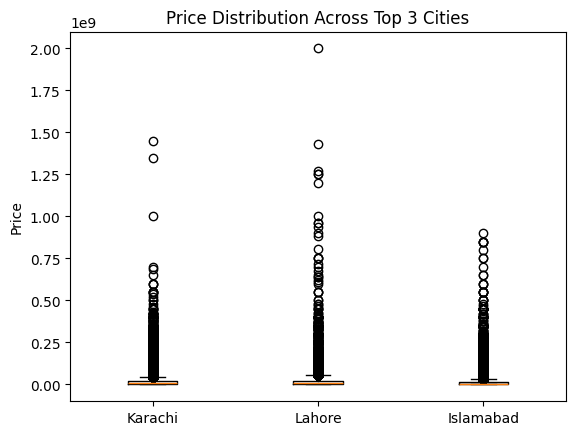

,price
city,
Lahore,11500000.0
Karachi,8500000.0
Islamabad,240000.0


In [22]:

# 5) Price vs Location (Boxplot) - top 3 cities
top3_cities = df_filtered["city"].value_counts().head(3).index.tolist()
df_top3 = df_filtered[df_filtered["city"].isin(top3_cities)]

data_box = [df_top3[df_top3["city"]==c]["price"].values for c in top3_cities]
plt.figure()
plt.boxplot(data_box, labels=top3_cities, showfliers=True)
plt.ylabel("Price")
plt.title("Price Distribution Across Top 3 Cities")
plt.show()

display(df_top3.groupby("city")["price"].median().sort_values(ascending=False))


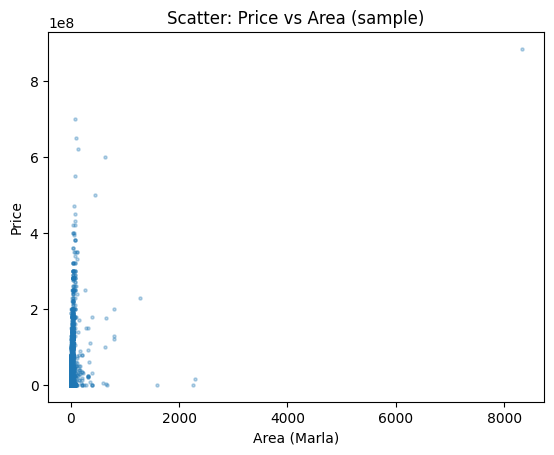

In [23]:

# 6) Price vs Area (Scatter)
sample = df_filtered.sample(n=min(20000, len(df_filtered)), random_state=42)
plt.figure()
plt.scatter(sample["area_in_marla"], sample["price"], s=5, alpha=0.3)
plt.xlabel("Area (Marla)")
plt.ylabel("Price")
plt.title("Scatter: Price vs Area (sample)")
plt.show()


/tmp/ipython-input-3259914522.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(baths_data, labels=[str(b) for b in baths_vals], showfliers=False)


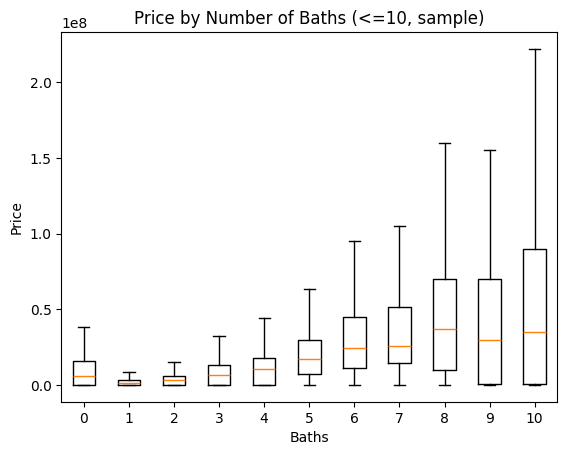

In [24]:

# 7) Bathrooms vs Price (Boxplot, baths <= 10)
sample2 = df_filtered[df_filtered["baths"]<=10].sample(n=min(30000, len(df_filtered[df_filtered["baths"]<=10])), random_state=42)
baths_vals = sorted(sample2["baths"].round().astype(int).unique())
baths_data = [sample2[sample2["baths"].round().astype(int)==b]["price"].values for b in baths_vals]

plt.figure()
plt.boxplot(baths_data, labels=[str(b) for b in baths_vals], showfliers=False)
plt.xlabel("Baths")
plt.ylabel("Price")
plt.title("Price by Number of Baths (<=10, sample)")
plt.show()


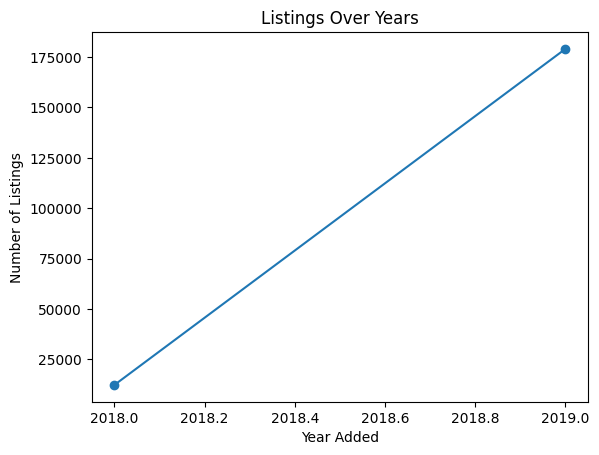

,count
year_added,
2018,12309
2019,179065


In [25]:

# 8) Date vs Count (Yearly listing trend)
year_counts = df_filtered["year_added"].value_counts().sort_index()
plt.figure()
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.xlabel("Year Added")
plt.ylabel("Number of Listings")
plt.title("Listings Over Years")
plt.show()

display(year_counts)


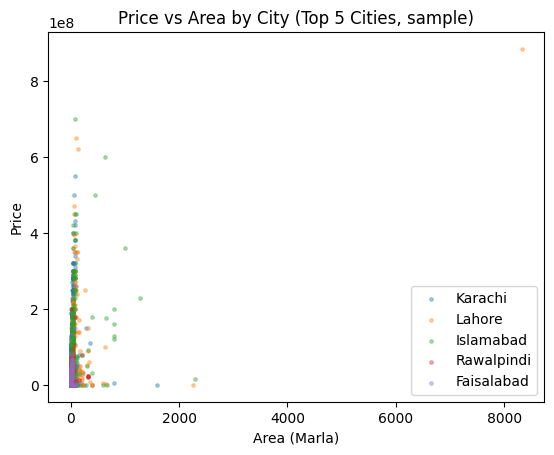

In [26]:

# 9) Price vs Area by City (Top 5 Cities)
top_cities = df_filtered["city"].value_counts().head(5).index.tolist()
sample3 = df_filtered[df_filtered["city"].isin(top_cities)].sample(
    n=min(25000, len(df_filtered[df_filtered["city"].isin(top_cities)])),
    random_state=42
)

plt.figure()
for c in top_cities:
    s = sample3[sample3["city"]==c]
    plt.scatter(s["area_in_marla"], s["price"], s=6, alpha=0.35, label=c)
plt.xlabel("Area (Marla)")
plt.ylabel("Price")
plt.title("Price vs Area by City (Top 5 Cities, sample)")
plt.legend()
plt.show()


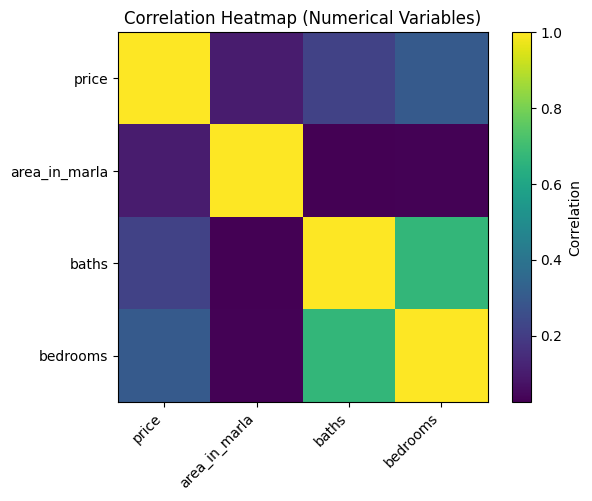

,price,area_in_marla,baths,bedrooms
price,1.000000,0.099913,0.219291,0.303068
area_in_marla,0.099913,1.000000,0.025535,0.030387
baths,0.219291,0.025535,1.000000,0.669033
bedrooms,0.303068,0.030387,0.669033,1.000000


In [27]:

# 10) Correlation matrix heatmap
corr_cols = ["price", "area_in_marla", "baths", "bedrooms"]
corr = df_filtered[corr_cols].corr(numeric_only=True)

plt.figure()
plt.imshow(corr.values)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap (Numerical Variables)")
plt.show()

display(corr)


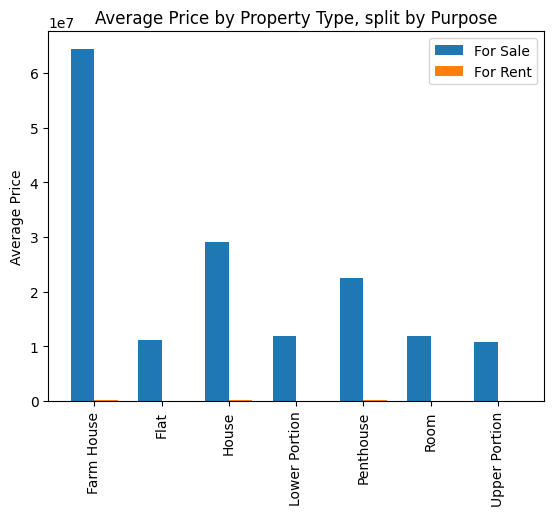

purpose,For Rent,For Sale
property_type,,
Farm House,212761.855670,6.436100e+07
Flat,49950.692821,1.116065e+07
House,157128.326535,2.915313e+07
Lower Portion,47641.563378,1.190079e+07
Penthouse,124625.000000,2.249206e+07
Room,18116.932271,1.183472e+07
Upper Portion,49574.631758,1.085155e+07


In [28]:

# 11) Property type pricing: avg price by property_type split by purpose (top 10 types)
group = df_filtered.groupby(["property_type", "purpose"])["price"].mean().unstack(fill_value=np.nan)
top_types = df_filtered["property_type"].value_counts().head(10).index
group_top = group.loc[group.index.intersection(top_types)]

x = np.arange(len(group_top.index))
width = 0.35
sale = group_top.get("For Sale", pd.Series(index=group_top.index, data=np.nan)).values
rent = group_top.get("For Rent", pd.Series(index=group_top.index, data=np.nan)).values

plt.figure()
plt.bar(x - width/2, sale, width, label="For Sale")
plt.bar(x + width/2, rent, width, label="For Rent")
plt.xticks(x, group_top.index.astype(str), rotation=90)
plt.ylabel("Average Price")
plt.title("Average Price by Property Type, split by Purpose")
plt.legend()
plt.show()

display(group_top)


## Phase 5: Business Questions (Q&A)

In [30]:

high_value_threshold = df_filtered["price"].quantile(0.90)
df_filtered["is_high_value"] = df_filtered["price"] >= high_value_threshold
print("High-value threshold (90th percentile):", high_value_threshold)


High-value threshold (90th percentile): 40000000.0


### Q1) Which city shows the highest growth in high-value properties over the years?

Top growth city: Lahore


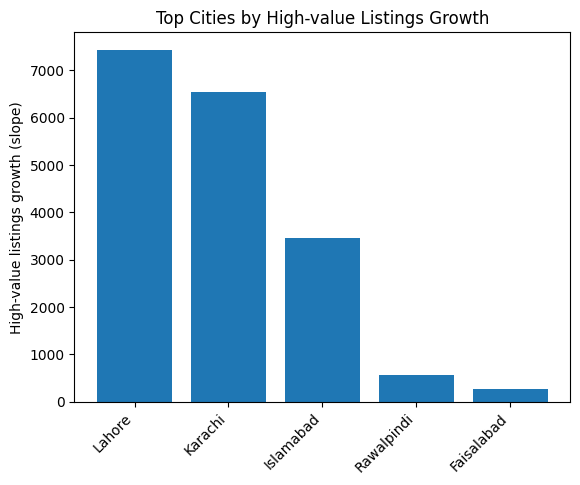

,0
Lahore,7437.0
Karachi,6549.0
Islamabad,3459.0
Rawalpindi,557.0
Faisalabad,261.0


In [31]:

hv = df_filtered[df_filtered["year_added"].notna()].copy()
hv_year_city = hv[hv["is_high_value"]].groupby(["city","year_added"]).size().reset_index(name="hv_count")

def slope_for_city(city):
    d = hv_year_city[hv_year_city["city"]==city].sort_values("year_added")
    if len(d) < 2:
        return np.nan
    x = d["year_added"].values.astype(float)
    y = d["hv_count"].values.astype(float)
    x = x - x.mean()
    return np.polyfit(x, y, 1)[0]

slopes = pd.Series({c: slope_for_city(c) for c in hv_year_city["city"].unique()}).dropna().sort_values(ascending=False)
print("Top growth city:", slopes.index[0] if len(slopes) else None)

top_slope = slopes.head(8)
plt.figure()
plt.bar(top_slope.index.astype(str), top_slope.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("High-value listings growth (slope)")
plt.title("Top Cities by High-value Listings Growth")
plt.show()

display(top_slope)


### Q2) What are the most popular property types in each city, and how has preference changed over time?

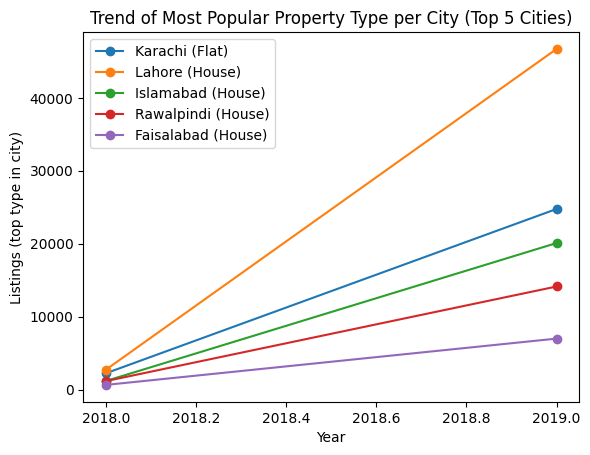

{'Karachi': 'Flat',
 'Lahore': 'House',
 'Islamabad': 'House',
 'Rawalpindi': 'House',
 'Faisalabad': 'House'}

In [32]:

top_cities = df_filtered["city"].value_counts().head(5).index.tolist()
q2 = {}

plt.figure()
for city in top_cities:
    d = df_filtered[(df_filtered["city"]==city) & (df_filtered["year_added"].notna())]
    top_type = d["property_type"].value_counts().idxmax()
    by_year = d[d["property_type"]==top_type].groupby("year_added").size().sort_index()
    q2[city] = {"top_type": top_type, "trend": by_year}
    plt.plot(by_year.index, by_year.values, marker="o", label=f"{city} ({top_type})")

plt.xlabel("Year")
plt.ylabel("Listings (top type in city)")
plt.title("Trend of Most Popular Property Type per City (Top 5 Cities)")
plt.legend()
plt.show()

display({c: q2[c]["top_type"] for c in q2})


### Q3) How do property prices vary with bedrooms across different cities and property types?

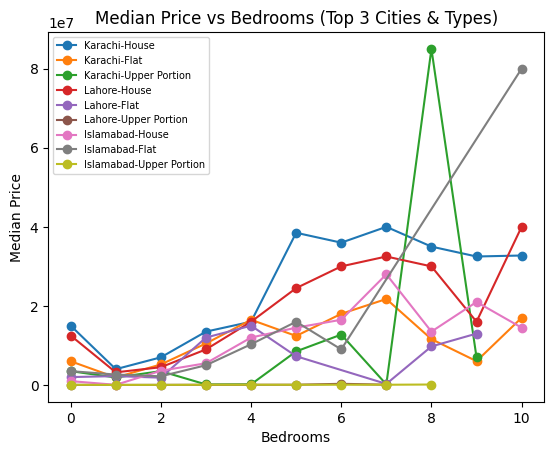

,city,property_type,bedrooms,price
0,Islamabad,Flat,0,3500000.0
1,Islamabad,Flat,1,2640000.0
2,Islamabad,Flat,2,2200000.0
3,Islamabad,Flat,3,5000000.0
4,Islamabad,Flat,4,10300000.0
5,Islamabad,Flat,5,16000000.0
6,Islamabad,Flat,6,9000000.0
7,Islamabad,Flat,10,80000000.0
8,Islamabad,House,0,980000.0
9,Islamabad,House,1,40000.0


In [33]:

top3_cities = df_filtered["city"].value_counts().head(3).index.tolist()
top3_types = df_filtered["property_type"].value_counts().head(3).index.tolist()

q3_table = (df_filtered[df_filtered["city"].isin(top3_cities) & df_filtered["property_type"].isin(top3_types)]
            .groupby(["city","property_type","bedrooms"])["price"].median()
            .reset_index()
            .sort_values(["city","property_type","bedrooms"]))

plt.figure()
for city in top3_cities:
    for ptype in top3_types:
        d = q3_table[(q3_table["city"]==city) & (q3_table["property_type"]==ptype) & (q3_table["bedrooms"]<=10)]
        if len(d):
            plt.plot(d["bedrooms"], d["price"], marker="o", label=f"{city}-{ptype}")
plt.xlabel("Bedrooms")
plt.ylabel("Median Price")
plt.title("Median Price vs Bedrooms (Top 3 Cities & Types)")
plt.legend(fontsize=7)
plt.show()

display(q3_table.head(20))


### Q4) Which agencies have the most listings in high-demand areas?

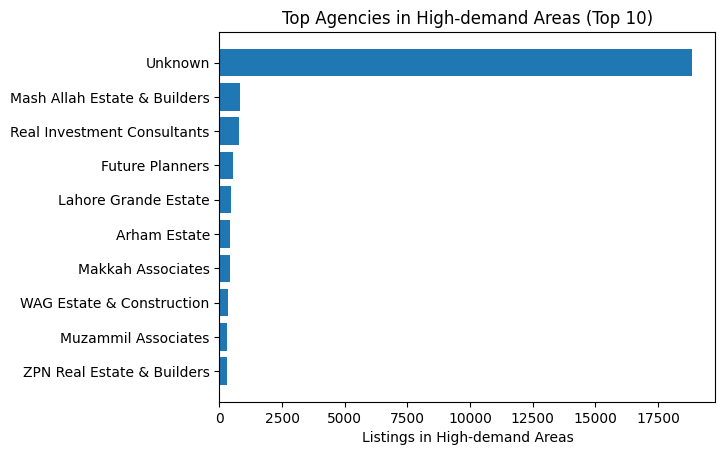

,city,location,cnt
840,Lahore,DHA Defence,11208
530,Karachi,DHA Defence,10927
1383,Rawalpindi,Bahria Town Rawalpindi,9277
510,Karachi,Bahria Town Karachi,8548
786,Lahore,Bahria Town,6510
559,Karachi,Gulistan-e-Jauhar,5877
565,Karachi,Gulshan-e-Iqbal Town,4513
320,Islamabad,DHA Defence,4026
990,Lahore,Johar Town,3212
631,Karachi,North Nazimabad,3094


,0
agency,
Unknown,18852
Mash Allah Estate & Builders,821
Real Investment Consultants,794
Future Planners,541
Lahore Grande Estate,455
Arham Estate,429
Makkah Associates,409
WAG Estate & Construction,351
Muzammil Associates,315


In [34]:

# Define high-demand areas as top 20 (city, location) pairs by listing volume within top 5 cities
top_cities = df_filtered["city"].value_counts().head(5).index.tolist()
hd = (df_filtered[df_filtered["city"].isin(top_cities)]
      .groupby(["city","location"]).size()
      .reset_index(name="cnt")
      .sort_values("cnt", ascending=False)
      .head(20))

hd_pairs = set(zip(hd["city"], hd["location"]))
in_hd = df_filtered[[ (c,l) in hd_pairs for c,l in zip(df_filtered["city"], df_filtered["location"]) ]]

top_agencies = in_hd.groupby("agency").size().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(top_agencies.index.astype(str)[::-1], top_agencies.values[::-1])
plt.xlabel("Listings in High-demand Areas")
plt.title("Top Agencies in High-demand Areas (Top 10)")
plt.show()

display(hd)
display(top_agencies)


### Q5) Is there a seasonal trend in property listings?

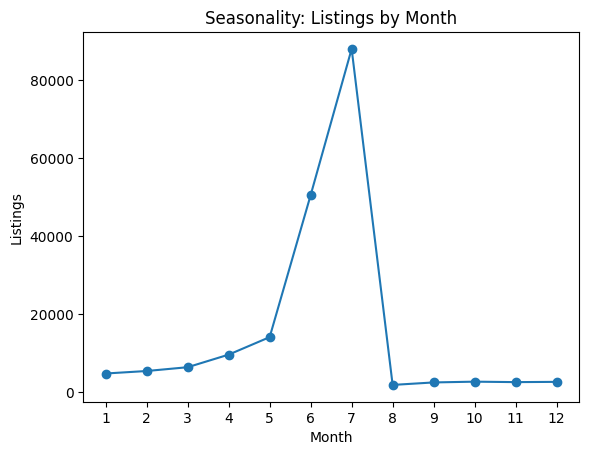

Peak month: 7


,count
month_added,
1,4800
2,5440
3,6414
4,9641
5,14130
6,50564
7,88054
8,1871
9,2509


In [35]:

month_counts = df_filtered["month_added"].value_counts().sort_index()

plt.figure()
plt.plot(month_counts.index, month_counts.values, marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Listings")
plt.title("Seasonality: Listings by Month")
plt.show()

print("Peak month:", int(month_counts.idxmax()) if len(month_counts) else None)
display(month_counts)


### Q6) How do sizes (Marla) correlate with prices across cities and property types?

/tmp/ipython-input-3931773873.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(corr_group)


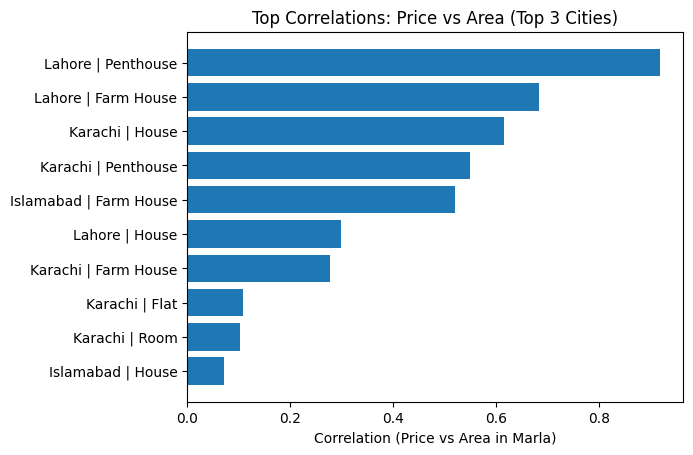

,city,property_type,corr_price_area
18,Lahore,Penthouse,0.917437
14,Lahore,Farm House,0.682643
9,Karachi,House,0.615388
11,Karachi,Penthouse,0.548831
0,Islamabad,Farm House,0.520945
16,Lahore,House,0.299220
7,Karachi,Farm House,0.276761
8,Karachi,Flat,0.108569
12,Karachi,Room,0.101781
2,Islamabad,House,0.071863


In [36]:

def corr_group(d):
    if len(d) < 10:
        return np.nan
    return d["price"].corr(d["area_in_marla"])

top3_cities = df_filtered["city"].value_counts().head(3).index.tolist()
q6_corr = (df_filtered[df_filtered["city"].isin(top3_cities)]
           .groupby(["city","property_type"])
           .apply(corr_group)
           .reset_index(name="corr_price_area")
           .sort_values("corr_price_area", ascending=False))

top_corr = q6_corr.dropna().head(10)

plt.figure()
plt.barh((top_corr["city"] + " | " + top_corr["property_type"]).astype(str)[::-1],
         top_corr["corr_price_area"].values[::-1])
plt.xlabel("Correlation (Price vs Area in Marla)")
plt.title("Top Correlations: Price vs Area (Top 3 Cities)")
plt.show()

display(top_corr)


### Q7) Which property types are more prevalent in certain provinces, and how does this impact prices?

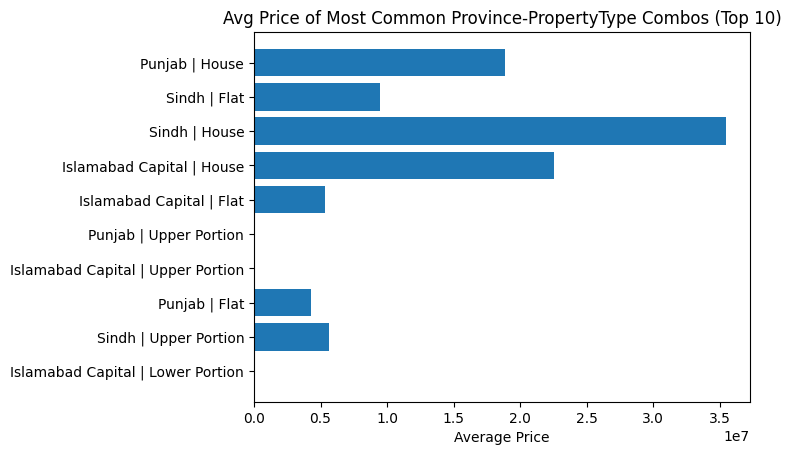

,province_name,property_type,listings,avg_price
9,Punjab,House,72367,1.883071e+07
15,Sindh,Flat,27001,9.468026e+06
16,Sindh,House,25258,3.548357e+07
2,Islamabad Capital,House,21276,2.253634e+07
1,Islamabad Capital,Flat,7513,5.339215e+06
13,Punjab,Upper Portion,7470,8.563674e+04
6,Islamabad Capital,Upper Portion,5984,8.247401e+04
8,Punjab,Flat,5642,4.273701e+06
20,Sindh,Upper Portion,5019,5.640683e+06
3,Islamabad Capital,Lower Portion,4719,5.706857e+04


In [37]:

prov_type = (df_filtered.groupby(["province_name","property_type"])["price"]
             .agg(listings="count", avg_price="mean")
             .reset_index())

top10 = prov_type.sort_values("listings", ascending=False).head(10)

plt.figure()
plt.barh((top10["province_name"] + " | " + top10["property_type"]).astype(str)[::-1],
         top10["avg_price"].values[::-1])
plt.xlabel("Average Price")
plt.title("Avg Price of Most Common Province-PropertyType Combos (Top 10)")
plt.show()

display(top10)


### Q8) How does the number of bathrooms influence prices in different cities?

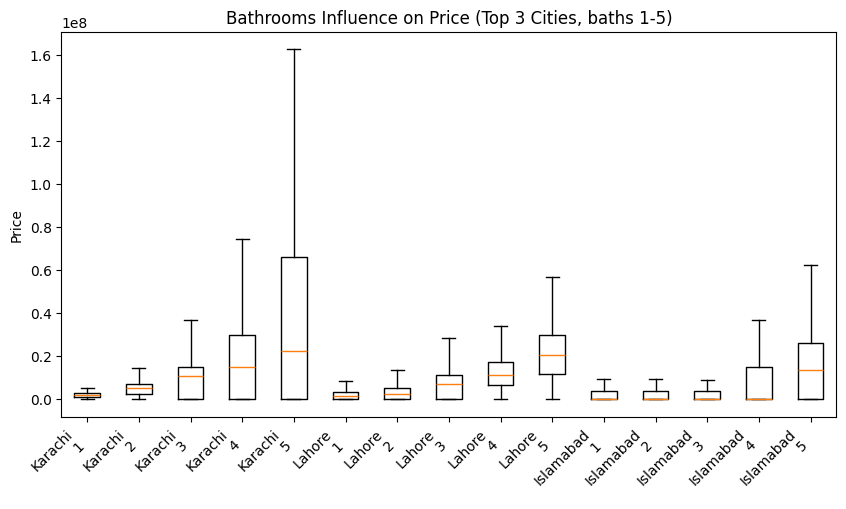

In [38]:

top3_cities = df_filtered["city"].value_counts().head(3).index.tolist()
df_baths = df_filtered[df_filtered["city"].isin(top3_cities) & (df_filtered["baths"]<=10)]

baths_levels = [1,2,3,4,5]

plt.figure(figsize=(10,5))
positions, labels, all_data = [], [], []
pos = 1
for city in top3_cities:
    for b in baths_levels:
        all_data.append(df_baths[(df_baths["city"]==city) & (df_baths["baths"].round().astype(int)==b)]["price"].values)
        positions.append(pos)
        labels.append(f"{city}\n{b}")
        pos += 1

plt.boxplot(all_data, positions=positions, showfliers=False)
plt.xticks(positions, labels, rotation=45, ha="right")
plt.ylabel("Price")
plt.title("Bathrooms Influence on Price (Top 3 Cities, baths 1-5)")
plt.show()


### Q9) What is the distribution of property purposes (For Sale vs For Rent) across cities?

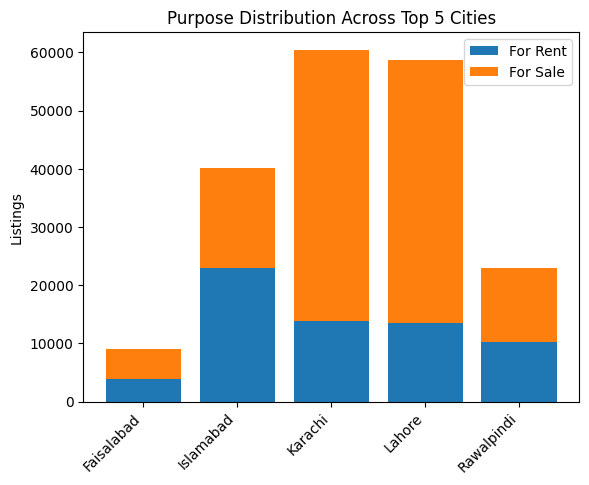

purpose,For Rent,For Sale
city,,
Faisalabad,3888,5192
Islamabad,22971,17216
Karachi,13815,46667
Lahore,13518,45213
Rawalpindi,10177,12717


In [39]:

top_cities = df_filtered["city"].value_counts().head(5).index.tolist()
purpose_city = pd.crosstab(df_filtered[df_filtered["city"].isin(top_cities)]["city"],
                           df_filtered[df_filtered["city"].isin(top_cities)]["purpose"])

plt.figure()
bottom = np.zeros(len(purpose_city))
x = np.arange(len(purpose_city.index))
for col in purpose_city.columns:
    vals = purpose_city[col].values
    plt.bar(x, vals, bottom=bottom, label=str(col))
    bottom += vals

plt.xticks(x, purpose_city.index.astype(str), rotation=45, ha="right")
plt.ylabel("Listings")
plt.title("Purpose Distribution Across Top 5 Cities")
plt.legend()
plt.show()

display(purpose_city)


### Q10) Which agents are most active in high-value property markets?

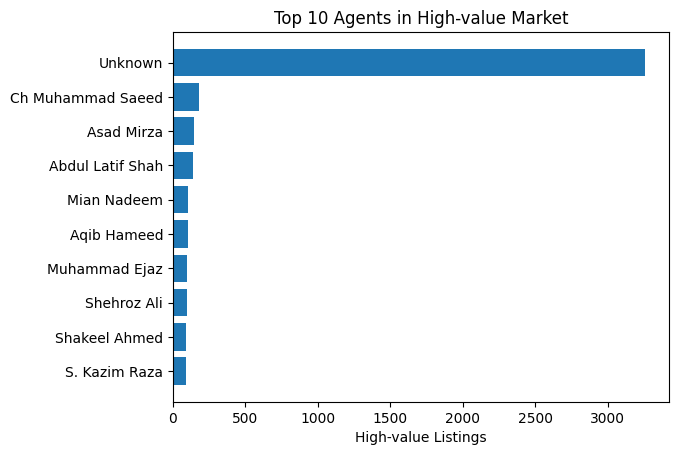

,0
agent,
Unknown,3260
Ch Muhammad Saeed,182
Asad Mirza,148
Abdul Latif Shah,140
Mian Nadeem,107
Aqib Hameed,102
Muhammad Ejaz,101
Shehroz Ali,97
Shakeel Ahmed,91


In [40]:

top_agents = df_filtered[df_filtered["is_high_value"]].groupby("agent").size().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(top_agents.index.astype(str)[::-1], top_agents.values[::-1])
plt.xlabel("High-value Listings")
plt.title("Top 10 Agents in High-value Market")
plt.show()

display(top_agents)
